In [1]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn.functional as F
from typing import Tuple
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm

In [2]:
class QAC_Agent():
    """ Since the discrete actions have been redefined as {0,1} by env, we can simply represent the action by a number. """
    def __init__(self,
                 actor_network:torch.nn, 
                 critic_network:torch.nn,
                 actor_optimizer:torch.optim,
                 critic_optimizer:torch.optim,
                 gamma:float = 0.9,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        self.device = device
        self.actor_network = actor_network
        self.critic_network = critic_network
        self.actor_optimizer = actor_optimizer
        self.critic_optimizer = critic_optimizer              
        self.gamma = gamma
        
    def get_action(self, obs:np.ndarray) -> int:        
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        dist = self.actor_network(obs)
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
               
        return picked_action.item()
    
    def calculate_log_prob(self, obs:torch.tensor, action:torch.tensor) -> torch.tensor:
        dist = F.softmax(self.actor_network(obs), dim=0)
        log_prob = torch.log(dist.gather(0, action))
        
        return log_prob
    
    def train_policy(self,
                     obs:np.ndarray,
                     action:int,
                     reward:float,
                     next_obs:np.ndarray,
                     next_action:int,
                     done:bool
                     ) -> None:
        
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        next_obs = torch.tensor(next_obs, dtype = torch.float32).to(self.device)
        
        current_Q = self.critic_network(obs)[action]
        next_Q = self.critic_network(next_obs)[next_action]
        TD_target = reward + self.gamma * next_Q * (1 - float(done))
        
        action = torch.tensor(action, dtype = torch.int64).to(self.device)
        log_prob = self.calculate_log_prob(obs, action)
        
        critic_loss =  F.mse_loss(current_Q, TD_target.detach())
        actor_loss = -log_prob * current_Q.detach()  # Detach means to fix the Q(s_t,a_t), so that the actor network will not be updated by the critic loss.
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
    

In [3]:
class Actor_Network(torch.nn.Module):

    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Actor_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    
class Critic_Network(torch.nn.Module):

    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Critic_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x

In [4]:
class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 episode_num:int = 1000,
                 eval_iters:int = 10,
                 actor_lr:float = 1e-3,
                 critic_lr:float = 1e-3,
                 gamma:float = 0.9,
                 seed = 0,
                 my_device = "cpu"
                 ) -> None:
        
        self.seed = seed
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(my_device)
    
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        _ = self.train_env.reset(seed=self.seed)
        _ = self.eval_env.reset(seed=self.seed+1)
        self.episode_num = episode_num
        obs_dim = gym.spaces.utils.flatdim(env.observation_space) 
        action_dim = env.action_space.n
        actor_network = Actor_Network(obs_dim,action_dim).to(self.device)
        critic_network = Critic_Network(obs_dim,action_dim).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        critic_optimizer = torch.optim.Adam(critic_network.parameters(),lr=critic_lr)
        self.agent = QAC_Agent(actor_network = actor_network, 
                               critic_network = critic_network,
                               actor_optimizer = actor_optimizer,
                               critic_optimizer = critic_optimizer,
                               gamma = gamma,
                               device = self.device)
        
        self.eval_iters = eval_iters
        self.eval_rewards = []    
        
    def train_episode(self) -> None:
        obs,_ = self.train_env.reset()
        done = False 
        while not done:
            action = self.agent.get_action(obs) 
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            next_action = self.agent.get_action(next_obs)
            self.agent.train_policy(obs, action, reward, next_obs, next_action, done)
            obs = next_obs
    
    def train(self) -> None:      
        with tqdm(total=self.episode_num, desc='Training') as pbar:        
            for _ in range(self.episode_num):
                self.train_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1)
    
    def eval(self) -> float:
        temp_test_rewards = []
        for _ in range(self.eval_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            temp_test_rewards.append(episode_reward)
            pass
        self.eval_rewards.append(temp_test_rewards)
        
        return np.mean(temp_test_rewards)

In [5]:
env = gym.make('CartPole-v0')
Manager = TrainManager(env = env,
                    episode_num = 1000,
                    eval_iters = 10,
                    actor_lr = 1e-3,
                    critic_lr= 1e-2,
                    gamma = 0.98,
                    seed = 0,
                    my_device = "cpu" 
                    )
Manager.train()

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Training: 100%|██████████| 1000/1000 [06:37<00:00,  2.52it/s, Avg. Test Reward=200]


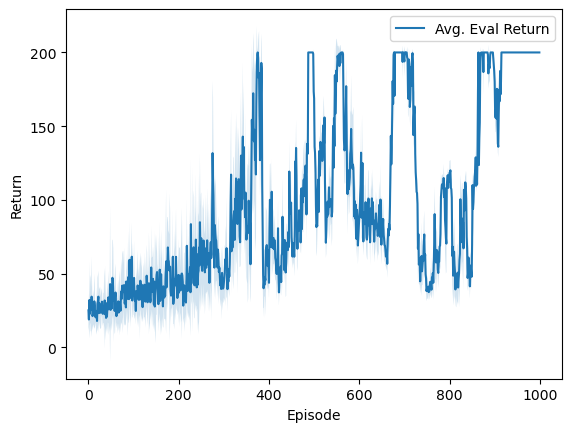

In [6]:
'''Plotting eval results'''
Manager.eval_rewards = np.array(Manager.eval_rewards)
means = np.mean(Manager.eval_rewards,axis=-1)
stds = np.std(Manager.eval_rewards,axis=-1)
plt.plot(means,label="Avg. Eval Return")
plt.fill_between(np.arange(len(means)),means-stds,means+stds,alpha=0.2)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()   